(control:examples:optimal-control:first-order-with-time-delay:ref-tracking)=
# First order system w/ time delay - Reference tracking

The same as the example [first order system - reference tracking](control:examples:optimal-control:first-order:ref-tracking), with a time delay from the input to the output.

**todo** 
* Comparison between frequency domain methods (PI controller,...) and time-domain methods (optimal control,...)

Need for [Padé approximation](system-theory:time-delay:pade) for time-domain method, in order to avoid dealing with delay differential equations.



## Libraries

In [2]:
# Install the control library if running in Colab
try:
    import control as ct
except ImportError:
    !python3.11 -m pip install control

import numpy as np
import scipy as sp
import control as ct
import matplotlib.pyplot as plt

print(ct.__version__)

0.10.2


## Plant model

**Plant model from mathworks.** https://www.mathworks.com/help/control/ug/temperature-control-in-a-heat-exchanger.html. First order + time delay. This example assumes **measurable disturbance** $d(t)$, so that they can feed a **feedforward** controller. This assumption is not made here. The plant is described by the following transfer functions between the output $Y(s) = T(s)$ (the measurement of temperature) and the control input $U(s) = V(s)$ (the voltage input to the heat exchanger) and the exogenous input $D$,

$$y(s) = \underbrace{ \frac{e^{-\tau s}}{a s + 1} u(s)}_{\text{control input}} + \underbrace{\frac{e^{-\tau_d s}}{a_d s + 1} d(s)}_{\text{exogenous input}} = G(s) u(s) + G_d(s) d(s) \ .$$

State-space realization, with $y(s) = x_1(s) + x_2(s)$, with $x_1$ from control input, and $x_2$ from disturbances,

$$\left\{\begin{aligned}
\begin{bmatrix} \dot{x}_1 \\ \dot{x}_2 \end{bmatrix} & = \begin{bmatrix} -\frac{1}{a} & \cdot \\ \cdot & -\frac{1}{a_d} \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} + \begin{bmatrix} \frac{1}{a} \\ \cdot \end{bmatrix} u(t-\tau) + \begin{bmatrix} \cdot \\ \frac{1}{a_d} \end{bmatrix} d(t-\tau_d) \\
 y & = \begin{bmatrix} \ 1 & 1 \ \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix}
\end{aligned}\right.$$

In [3]:
#> Parameters of the system
a  , tau   = 21.3, 14.7
a_d, tau_d = 25.0, 35.0

#> Transfer function output/control input
num_G = [1]
den_G = [a, 1]
G_no_delay = ct.TransferFunction(num_G, den_G)

# w/o Padé approximation of time delay
G_pure = G_no_delay.copy()
G_pure.io_delay = tau

# w/ Padè approximation of time delay
# Rational approximation is required by control library to:
# - perform state-space realization
# - time-domain simulation
# - time-domain control design
n_pade = 4
num_delay, den_delay = ct.pade(tau, n_pade)
G_delay_pade = ct.TransferFunction(num_delay, den_delay)

G_pade = ct.series(G_no_delay, G_delay_pade)

#> Transfer function output/disturbance
num_G_d = [1]
den_G_d = [a_d, 1]
G_d_no_delay = ct.TransferFunction(num_G_d, den_G_d)

# w/o Padé approximation of time delay
G_d_pure = G_d_no_delay.copy()
G_d_pure.io_delay = tau_d

# w/ Padè approximation of time delay
# Rational approximation is required by control library to:
# - perform state-space realization
# - time-domain simulation
# - time-domain control design
n_pade = 4
num_d_delay, den_d_delay = ct.pade(tau_d, n_pade)
G_d_delay_pade = ct.TransferFunction(num_d_delay, den_d_delay)

G_d_pade = ct.series(G_d_no_delay, G_d_delay_pade)


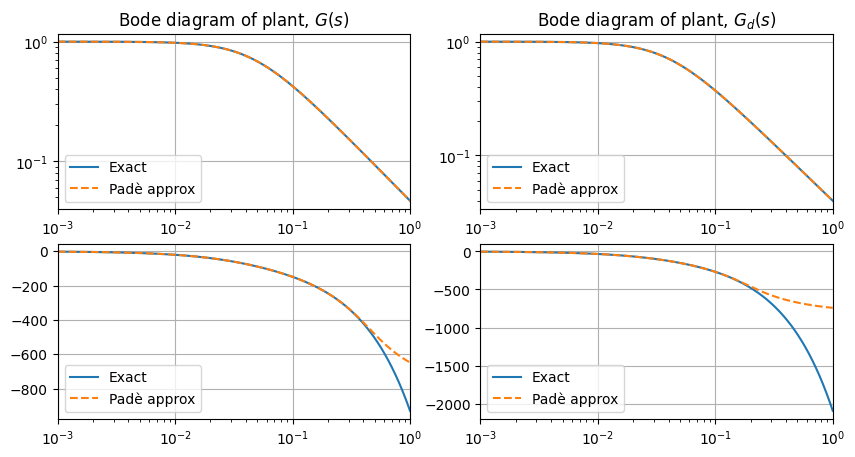

In [4]:
# Plotting
fig, ax = plt.subplots(2,2, figsize=(10,5))

# Bode plot for both
# Note: plot=False allows us to capture data or customize the plot easily
omega = np.logspace(-3, 0, 500)
G_pure_jom = G_pure.frequency_response(omega)
G_pade_jom = G_pade.frequency_response(omega)

G_d_pure_jom = G_d_pure.frequency_response(omega)
G_d_pade_jom = G_d_pade.frequency_response(omega)

# Manually add time delay to G_pure, as it looks like it's not getting time delay

ax[0,0].plot(G_pure_jom.omega, G_pure_jom.magnitude, label='Exact')
ax[0,0].plot(G_pade_jom.omega, G_pade_jom.magnitude, '--', label='Padè approx')
ax[0,0].legend()
ax[0,0].set_xscale('log')
ax[0,0].set_yscale('log')
ax[0,0].set_xlim(omega[0], omega[-1])
ax[0,0].grid()

ax[1,0].plot(G_pure_jom.omega, np.rad2deg(np.unwrap(G_pure_jom.phase - omega * tau)), label='Exact')
ax[1,0].plot(G_pade_jom.omega, np.rad2deg(np.unwrap(G_pade_jom.phase)), '--', label='Padè approx')
ax[1,0].legend()
ax[1,0].set_xscale('log')
ax[1,0].set_xlim(omega[0], omega[-1])
ax[1,0].grid()


ax[0,1].plot(G_pure_jom.omega, G_d_pure_jom.magnitude, label='Exact')
ax[0,1].plot(G_pade_jom.omega, G_d_pade_jom.magnitude, '--', label='Padè approx')
ax[0,1].legend()
ax[0,1].set_xscale('log')
ax[0,1].set_yscale('log')
ax[0,1].set_xlim(omega[0], omega[-1])
ax[0,1].grid()

ax[1,1].plot(G_pure_jom.omega, np.rad2deg(np.unwrap(G_d_pure_jom.phase - omega * tau_d)), label='Exact')
ax[1,1].plot(G_pade_jom.omega, np.rad2deg(np.unwrap(G_d_pade_jom.phase)), '--', label='Padè approx')
ax[1,1].legend()
ax[1,1].set_xscale('log')
ax[1,1].set_xlim(omega[0], omega[-1])
ax[1,1].grid()

ax[0,0].set_title(f"Bode diagram of plant, $G(s)$")
ax[0,1].set_title(f"Bode diagram of plant, $G_d(s)$")

plt.show()

## Control design

Here a low-order regulator with TF $R(s)$ is designed for tracking a desired step-input.

The regulator takes the tracking error $e(t)$ as an input and returns the plant control input $u(t)$ as its output. Using TF algebra in Laplace domain (for the forced response)

$$\begin{aligned}
  y & = G u + G_d d = G R e + G_d d = G R ( y_{\text{ref}} - y ) + G_d d \\
  e & = y_{\text{ref}} - y = y_{\text{ref}} - G R e - G_d d \\
\end{aligned}$$

so that the closed-loop TFs are

$$\begin{aligned}
  y & = \frac{G R}{1 + G R} y_{\text{ref}} + \frac{G_d}{1 + G R} d =: T(s) y_{\text{ref}} + \frac{G_d}{1 + G R} d \\
  e & = \frac{1}{1 + G R} y_{\text{ref}} - \frac{G_d}{1 + G R} d =: S(s) y_{\text{ref}} - \frac{G_d}{1 + G R} d \ .
\end{aligned}$$

The control input can be written as a function of $y_{\text{ref}}$ and $d$ as well

$$u = R e = R y_{\text{ref}} - R y = R y_{\text{ref}} - R G u - R G_d d \ ,$$

so that

$$u = \frac{R}{1 + R G} y_{\text{ref}} - \frac{RG_d}{1 + RG} d \ .$$


### PI controller

With $e(t) := y_{\text{ref}}(t) - y(t)$

$$\begin{aligned}
  u(t) & = K_p e(t) + K_i \int_{\tau = 0}^{t} e(\tau) d \tau \\
  u(s) & = \left[ K_p + \frac{K_i}{s} \right] e(s) = R(s) e(s)
\end{aligned}$$

**Open-loop TF** from error to output $y(s) = L(s) e(s) = R(s) G(s) e(s)$ reads

$$L(s) = \frac{s K_p + K_i}{s} \frac{e^{-\tau s}}{a s + 1}$$


In [6]:
#> Parameters of the PI controller
Kc = 1.01
tau_c = 25.8

Kp, Ki = Kc, Kc/tau_c

num_PI = [Kp, Ki]
den_PI = [1, 0]
R_PI = ct.TransferFunction(num_PI, den_PI)


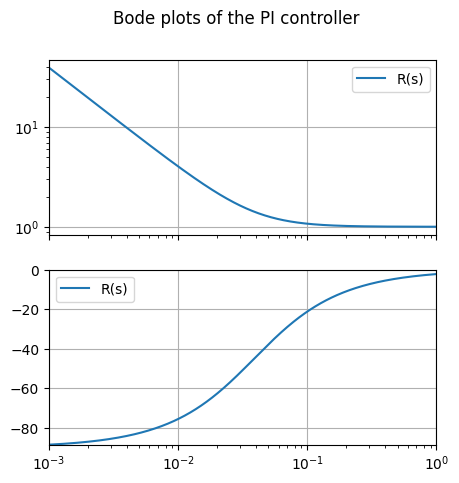

In [9]:
R_PI_jom = R_PI.frequency_response(omega)

fig, ax = plt.subplots(2,1, figsize=(5,5))
ax[0].plot(R_PI_jom.omega, R_PI_jom.magnitude, label='R(s)')
ax[0].legend()
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlim(omega[0], omega[-1])
ax[0].set_xticklabels([])
ax[0].grid()

ax[1].plot(R_PI_jom.omega, np.rad2deg(np.unwrap(R_PI_jom.phase)), label='R(s)')
ax[1].legend()
ax[1].set_xscale('log')
ax[1].set_xlim(omega[0], omega[-1])
ax[1].set_ylim(np.min(np.rad2deg(np.unwrap(R_PI_jom.phase))), np.max([0, np.max(np.rad2deg(np.unwrap(R_PI_jom.phase)))]))
ax[1].grid()

fig.suptitle("Bode plots of the PI controller")
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


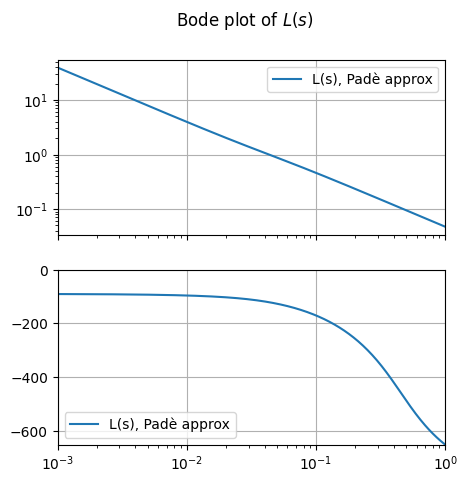

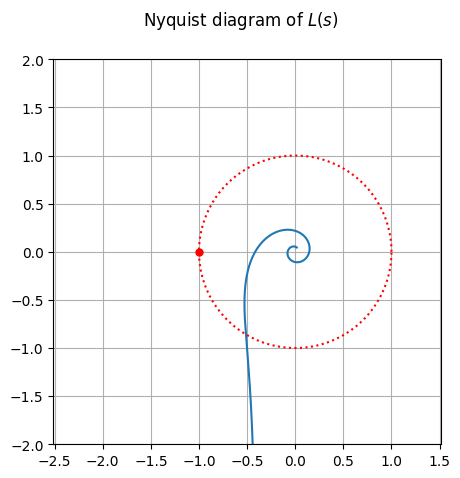

In [10]:
#> Open-loop transfer function
L_pade = ct.series(R_PI, G_pade)

#> Frequency response of the open-loop TF
L_pade_jom = L_pade.frequency_response(omega)

fig, ax = plt.subplots(2,1, figsize=(5,5))
ax[0].plot(L_pade_jom.omega, L_pade_jom.magnitude, label='L(s), Padè approx')
ax[0].legend()
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlim(omega[0], omega[-1])
ax[0].set_xticklabels([])
ax[0].grid()

ax[1].plot(L_pade_jom.omega, np.rad2deg(np.unwrap(L_pade_jom.phase)), label='L(s), Padè approx')
ax[1].legend()
ax[1].set_xscale('log')
ax[1].set_xlim(omega[0], omega[-1])
ax[1].set_ylim(np.min(np.rad2deg(np.unwrap(L_pade_jom.phase))), np.max([0, np.max(np.rad2deg(np.unwrap(L_pade_jom.phase)))]))
ax[1].grid()

fig.suptitle("Bode plot of $L(s)$")

#> Nyquist plot
side_l = 4
xc, yc = -.5, 0.
L_pade_jom_complex = L_pade_jom.magnitude * np.exp(1j * L_pade_jom.phase)

fig, ax = plt.subplots(figsize=(5,5))
ax.plot(np.real(L_pade_jom_complex), np.imag(L_pade_jom_complex))
ax.plot([-1], [0], 'o', ms=5, color='red')
ax.plot(np.cos(np.linspace(0,2*np.pi,100)), np.sin(np.linspace(0,2*np.pi,100)), ':', color='red')
ax.axis('equal')
ax.set_xlim(xc-side_l/2, xc+side_l/2)
ax.set_ylim(yc-side_l/2, yc+side_l/2)
fig.suptitle("Nyquist diagram of $L(s)$")
ax.grid()


### Optimal controller

## Closed-loop transfer functions - gang of the four

In [11]:
G_jom_complex = G_pade_jom.magnitude * np.exp(1j * G_pade_jom.phase)
R_jom_complex = R_PI.frequency_response(omega).magnitude * np.exp(1j * R_PI.frequency_response(omega).phase)

G_d_jom_complex = G_d_pade_jom.magnitude * np.exp(1j * G_d_pade_jom.phase)

#> Sensitivity, S = 1 / ( 1 + L )
S_jom_complex = 1 / ( 1 + L_pade_jom_complex )

#> Complementary sensitivity, T = L / ( 1 + L )
T_jom_complex = L_pade_jom_complex / ( 1 + L_pade_jom_complex )

#> Load sensitivity, PS = G / ( 1 + L )
PS_jom_complex = G_jom_complex / ( 1 + L_pade_jom_complex )

#> Noise sensitivity, CS = R / ( 1 + L )
CS_jom_complex = R_jom_complex / ( 1 + L_pade_jom_complex )

#> From disturbance to tracking error (or to output), Gd / ( 1 + L )
PS_d_jom_complex = G_d_jom_complex / ( 1 + L_pade_jom_complex )

#> From disturbance d to control input u, R Gd / ( 1 + L )
T_d_jom_complex = R_jom_complex * G_d_jom_complex / ( 1 + L_pade_jom_complex )



Text(0.5, 0, '$\\omega$')

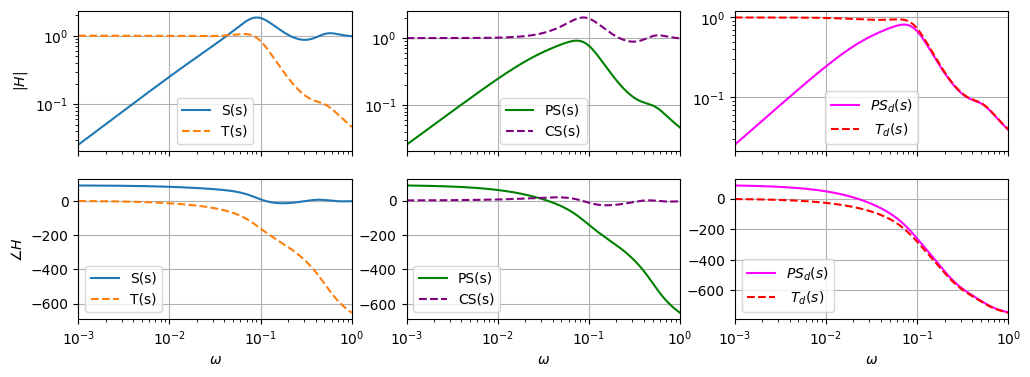

In [12]:
#> Frequency response of the open-loop TF
L_pade_jom = L_pade.frequency_response(omega)

fig, ax = plt.subplots(2,3, figsize=(12,4))
ax[0,0].plot(omega, np.abs( S_jom_complex),       label='S(s)')
ax[0,0].plot(omega, np.abs( T_jom_complex), '--', label='T(s)')
ax[0,0].legend()
ax[0,0].set_xscale('log')
ax[0,0].set_yscale('log')
ax[0,0].set_xlim(omega[0], omega[-1])
ax[0,0].set_xticklabels([])
ax[0,0].grid()

ax[1,0].plot(omega, np.rad2deg(np.unwrap(np.angle( S_jom_complex))),       label='S(s)')
ax[1,0].plot(omega, np.rad2deg(np.unwrap(np.angle( T_jom_complex))), '--', label='T(s)')
ax[1,0].legend()
ax[1,0].set_xscale('log')
ax[1,0].set_xlim(omega[0], omega[-1])
ax[1,0].grid()


ax[0,1].plot(omega, np.abs(PS_jom_complex),       label='PS(s)', color='green')
ax[0,1].plot(omega, np.abs(CS_jom_complex), '--', label='CS(s)', color='purple')
ax[0,1].legend()
ax[0,1].set_xscale('log')
ax[0,1].set_yscale('log')
ax[0,1].set_xlim(omega[0], omega[-1])
ax[0,1].set_xticklabels([])
ax[0,1].grid()

ax[1,1].plot(omega, np.rad2deg(np.unwrap(np.angle(PS_jom_complex))),       label='PS(s)', color='green')
ax[1,1].plot(omega, np.rad2deg(np.unwrap(np.angle(CS_jom_complex))), '--', label='CS(s)', color='purple')
ax[1,1].legend()
ax[1,1].set_xscale('log')
ax[1,1].set_xlim(omega[0], omega[-1])
ax[1,1].grid()


ax[0,2].plot(omega, np.abs(PS_d_jom_complex),       label='$PS_d(s)$', color='magenta')
ax[0,2].plot(omega, np.abs( T_d_jom_complex), '--', label=' $T_d(s)$', color='red')
ax[0,2].legend()
ax[0,2].set_xscale('log')
ax[0,2].set_yscale('log')
ax[0,2].set_xlim(omega[0], omega[-1])
ax[0,2].set_xticklabels([])
ax[0,2].grid()

ax[1,2].plot(omega, np.rad2deg(np.unwrap(np.angle(PS_d_jom_complex))),       label=r'$PS_d(s)$', color='magenta')
ax[1,2].plot(omega, np.rad2deg(np.unwrap(np.angle( T_d_jom_complex))), '--', label=r' $T_d(s)$', color='red')
ax[1,2].legend()
ax[1,2].set_xscale('log')
ax[1,2].set_xlim(omega[0], omega[-1])
ax[1,2].grid()


ax[0,0].set_ylabel(r"$|H|$")
ax[1,0].set_ylabel(r"$\angle H$")
ax[1,0].set_xlabel(r"$\omega$")
ax[1,1].set_xlabel(r"$\omega$")
ax[1,2].set_xlabel(r"$\omega$")


# ax[1].plot(L_pade_jom.omega, np.rad2deg(np.unwrap(L_pade_jom.phase)), label='L(s), Padè approx')
# ax[1].legend()
# ax[1].set_xscale('log')
# ax[1].set_xlim(omega[0], omega[-1])
# ax[1].set_ylim(np.min(np.rad2deg(np.unwrap(L_pade_jom.phase))), np.max([0, np.max(np.rad2deg(np.unwrap(L_pade_jom.phase)))]))
# ax[1].grid()

### Time-domain response

In [14]:
# todo:
# - evaluate the proper TF from distrubance to y
# - repeat the process to get the control input as the output of closed-loop systems
#   as a function of reference signal and of disturbance, in order to show the input load

sys_cl = ct.feedback(ct.series(R_PI, G_pade), 1)
sys_cl_d = G_d_pade / ( 1 + R_PI * G_pade )
sys_cl_u_ref =  R_PI / ( 1 + R_PI * G_pade )
sys_cl_u_d   = -R_PI * G_d_pade / ( 1 + R_PI * G_pade )


In [15]:
#> Step response
time = np.linspace(0, 300, 1000)
t, y = ct.step_response(sys_cl      , time)
t, u = ct.step_response(sys_cl_u_ref, time)

#> Response to harmonic disturbances
# obs T_d(omega = 1) ~ 0.04
omega_d = 1.0
ampl_d = 1.
d = ampl_d * np.cos(omega_d * time)
t, y_d = ct.forced_response(sys_cl_d  , time, d)
t, u_d = ct.forced_response(sys_cl_u_d, time, d)

print(np.abs(G_d_jom_complex[-1]))  # if omega 1 is the last element of the omega vector


0.03996803834887157


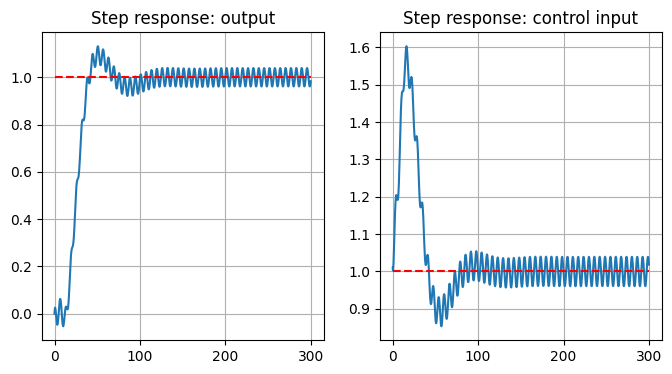

In [16]:
fig, ax = plt.subplots(1,2, figsize=(8, 4))
ax[0].plot(t, y+y_d)
ax[0].plot(t, np.ones(np.shape(t)), '--', color='red')
ax[0].set_title("Step response: output")
ax[0].grid()

ax[1].plot(t, u+u_d)
ax[1].plot(t, np.ones(np.shape(t)), '--', color='red')
ax[1].set_title("Step response: control input")
ax[1].grid()

plt.show()


**Model error using Padé approximation in time simulation.** Only Padé approximation for time delay is supported for state-space representation and time response simulation. Here, the response to a step of closed-loop system with Padé approximation of the time delay is non-zero in $t \in [0, \tau]$, but shows "small-amplitude" oscillations.

**Effect of the disturbances.** Here the harmonic disturbances have frequency $\omega_d$ much larger than the cutting frequency $\omega_c$. Thus, $d$ produces the output $y_d(\omega_d) = T_d(\omega_d) d(\omega_d)$, with gain $|G(\omega_d)| \simeq .04$ Thus, even with a disturbance $d$ with the same amplitude as the reference step signal, the oscillations around the desired output have "small" amplitude, $y_d \simeq A_d \cos( \omega_d t + \varphi_d)$, with $A_d = |T_d(\omega_d)| |d(\omega_d)| \simeq .04 |d(\omega_d)|$.